# 📊 E-commerce Product Analytics: Customer Behavior, Retention & Revenue Insights

**Датасет:** [Online Retail Dataset — Kaggle](https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset)
**Стек:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQL-style aggregations, Jupyter Notebook

---

## О проекте

Транзакционные данные интернет-магазина за период 2010–2011 гг. (UK-based online retailer, продажа подарочных
товаров). Каждая строка — позиция в заказе (invoice line item): товар, количество, цена, дата, покупатель, страна.

## Бизнес-вопросы (Business Questions)

1. Как меняется выручка компании во времени? Есть ли сезонность?
2. Какие страны и товары приносят наибольший доход (принцип Парето 80/20)?
3. Насколько лояльна клиентская база? Какой у нас Repeat Purchase Rate и retention по когортам?
4. Можно ли сегментировать клиентов по покупательскому поведению (RFM) для персонализированных
   маркетинговых кампаний?
5. Какие продуктовые метрики (KPI) стоит регулярно отслеживать команде и почему?

## Структура ноутбука

1. Импорты и загрузка данных
2. Очистка и предобработка (Data Cleaning)
3. Разведочный анализ (EDA): выручка во времени, топ страны/товары
4. Ключевые продуктовые метрики (Revenue, AOV, Orders, Active Customers, Repeat Rate)
5. Когортный анализ retention
6. RFM-сегментация клиентов
7. Анализ товарного ассортимента (Pareto 80/20)
8. Выводы и бизнес-рекомендации

## 1. Импорты и загрузка данных

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import kagglehub

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [ ]:
path =  kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")
df = pd.read_csv(f"{path}/online_retail.csv", encoding="ISO-8859-1")
df.head()


Using Colab cache for faster access to the 'online-retail-dataset' dataset.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [ ]:
df.info()
print("\nПропуски по колонкам:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Пропуски по колонкам:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 2. Очистка и предобработка данных


In [ ]:
df_clean = df.copy()

df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

n_before = len(df_clean)

# 1. Убираем отменённые заказы
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")]

# 2. Убираем строки без CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# 3. Убираем некорректные количества и цены
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

# 4. Убираем дубликаты
df_clean = df_clean.drop_duplicates()

# 5. Добавляем производные поля
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
df_clean["InvoiceDateOnly"] = df_clean["InvoiceDate"].dt.date

n_after = len(df_clean)
print(f"Строк до очистки: {n_before:,}")
print(f"Строк после очистки: {n_after:,}")
print(f"Удалено: {n_before - n_after:,} ({(n_before - n_after) / n_before:.1%})")

df_clean.head()


Строк до очистки: 541,909
Строк после очистки: 392,692
Удалено: 149,217 (27.5%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,InvoiceDateOnly
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01


## 3. Разведочный анализ (EDA)

### 3.1 Динамика выручки во времени

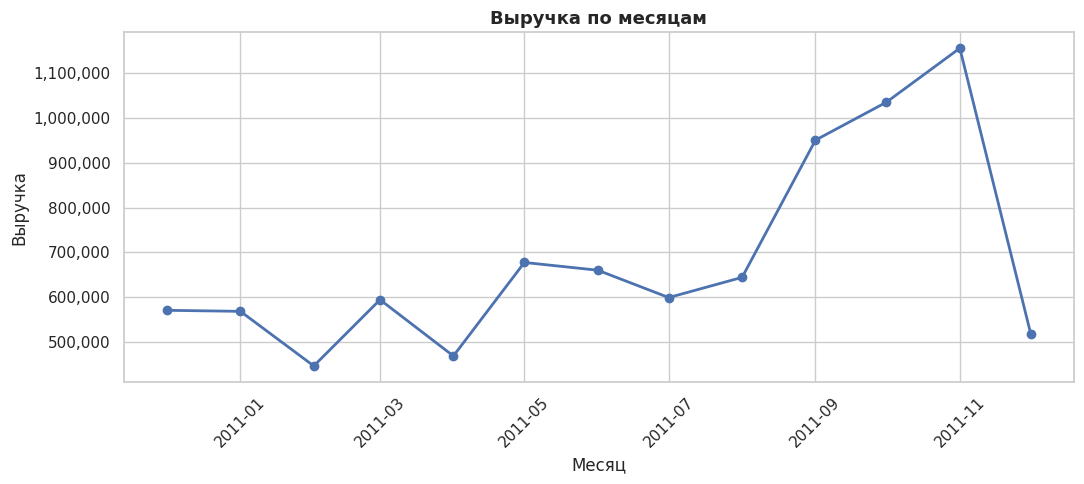

In [ ]:
monthly_revenue = (
    df_clean.groupby("InvoiceMonth")["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values("InvoiceMonth")
)

fig, ax = plt.subplots()
ax.plot(monthly_revenue["InvoiceMonth"], monthly_revenue["TotalPrice"],
        marker="o", linewidth=2)
ax.set_title("Выручка по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Выручка")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Топ-10 стран по выручке

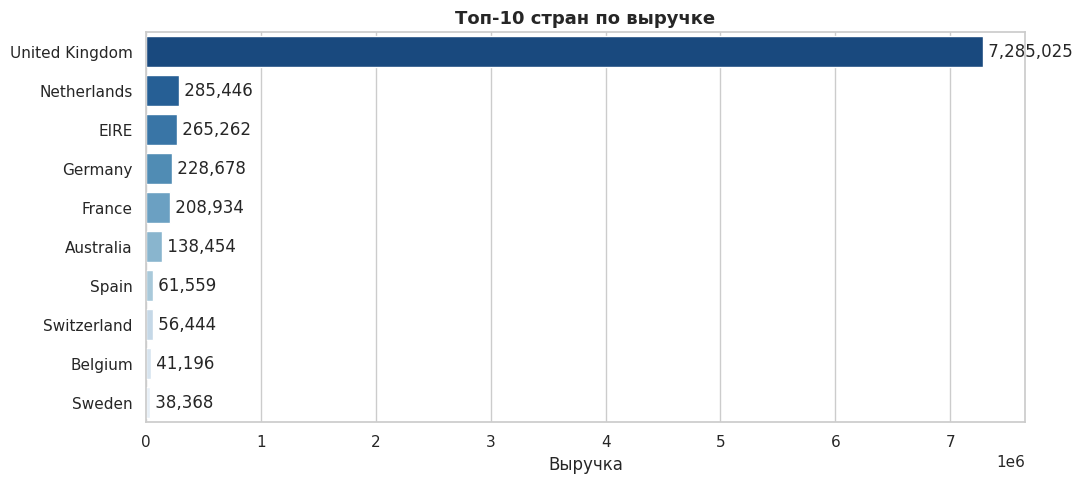

In [ ]:
top_countries = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette="Blues_r")
ax.set_title("Топ-10 стран по выручке")
ax.set_xlabel("Выручка")
ax.set_ylabel("")
for i, v in enumerate(top_countries.values):
    ax.text(v, i, f" {v:,.0f}", va="center")
plt.tight_layout()
plt.show()


### 3.3 Топ-10 товаров по выручке

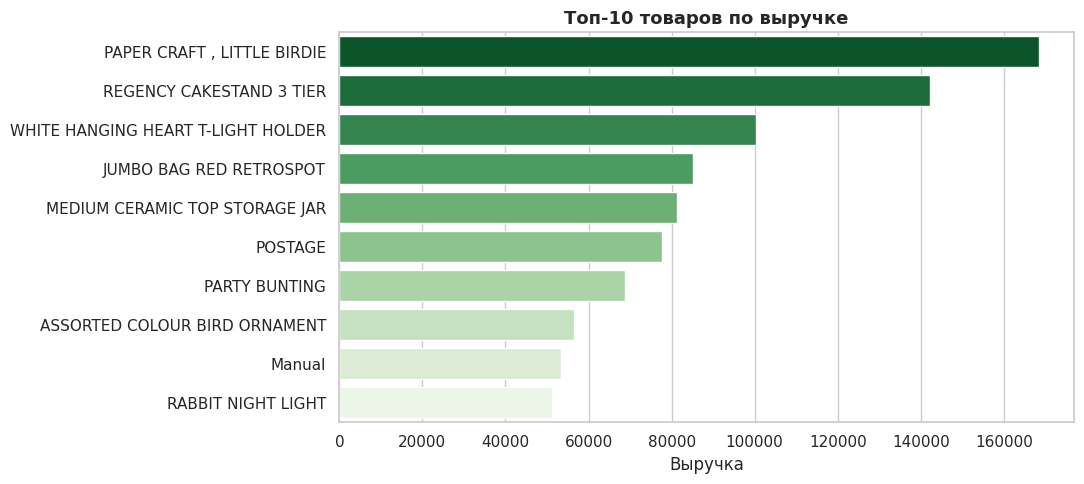

In [ ]:
top_products = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette="Greens_r")
ax.set_title("Топ-10 товаров по выручке")
ax.set_xlabel("Выручка")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. Ключевые продуктовые метрики (KPI)

- **Revenue** — суммарная выручка;
- **Orders** — количество уникальных заказов;
- **Active Customers** — количество уникальных покупателей;
- **AOV (Average Order Value)** — средний чек;
- **Repeat Purchase Rate** — доля клиентов с более чем одной покупкой (proxy retention/loyalty).


In [ ]:
total_revenue = df_clean["TotalPrice"].sum()
total_orders = df_clean["InvoiceNo"].nunique()
active_customers = df_clean["CustomerID"].nunique()
aov = total_revenue / total_orders

orders_per_customer = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_customers = (orders_per_customer > 1).sum()
repeat_purchase_rate = repeat_customers / active_customers

kpi_summary = pd.DataFrame({
    "Метрика": ["Total Revenue (£)", "Total Orders", "Active Customers",
                "Average Order Value (AOV, £)", "Repeat Purchase Rate"],
    "Значение": [
        f"{total_revenue:,.0f}",
        f"{total_orders:,}",
        f"{active_customers:,}",
        f"{aov:,.2f}",
        f"{repeat_purchase_rate:.1%}",
    ],
})
kpi_summary


,Метрика,Значение
0,Total Revenue (£),"8,887,209"
1,Total Orders,"18,532"
2,Active Customers,"4,338"
3,"Average Order Value (AOV, £)",479.56
4,Repeat Purchase Rate,65.6%


## 5. Когортный анализ retention

Когорта определяется по месяцу первой покупки клиента. Далее считаем, какой процент клиентов
каждой когорты продолжает покупать в последующие месяцы (`cohort_index`).


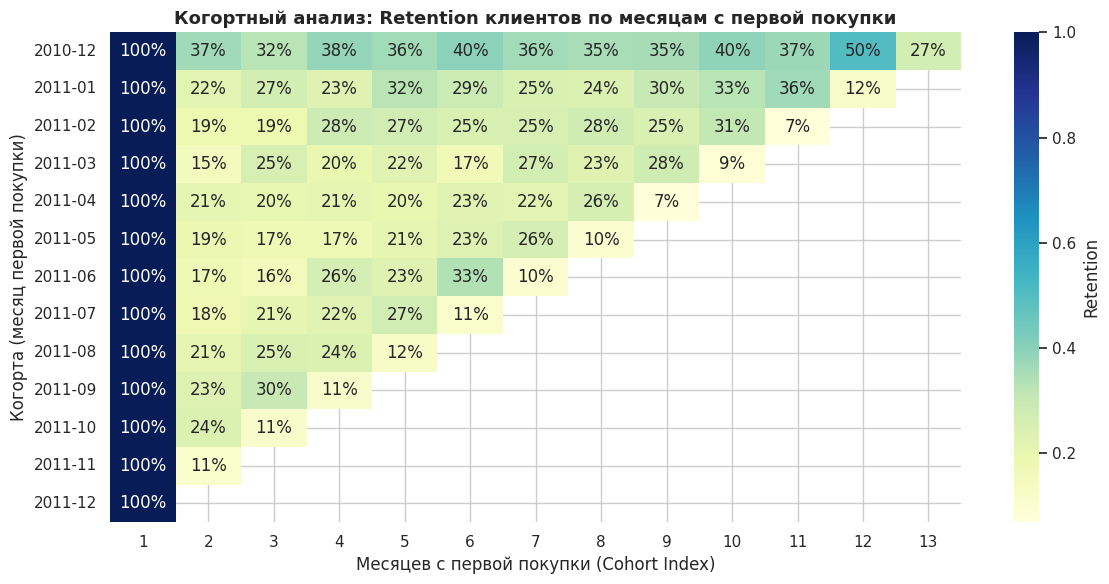

Средний retention на 2-й месяц после первой покупки: 20.6%


In [ ]:
df_cohort = df_clean.copy()

df_cohort["CohortMonth"] = (
    df_cohort.groupby("CustomerID")["InvoiceMonth"].transform("min")
)

def month_diff(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

df_cohort["CohortIndex"] = month_diff(df_cohort["InvoiceMonth"], df_cohort["CohortMonth"]) + 1

cohort_data = (
    df_cohort.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention.index = retention.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Retention"})
ax.set_title("Когортный анализ: Retention клиентов по месяцам с первой покупки")
ax.set_xlabel("Месяцев с первой покупки (Cohort Index)")
ax.set_ylabel("Когорта (месяц первой покупки)")
plt.tight_layout()
plt.show()

avg_m1_retention = retention[2].mean() if 2 in retention.columns else np.nan
print(f"Средний retention на 2-й месяц после первой покупки: {avg_m1_retention:.1%}"
      if pd.notna(avg_m1_retention) else "Недостаточно данных для расчёта retention на 2-й месяц")


## 6. RFM-сегментация клиентов

**RFM**:

- **Recency (R)** — сколько дней прошло с последней покупки клиента;
- **Frequency (F)** — сколько заказов сделал клиент;
- **Monetary (M)** — сколько клиент потратил всего.

По каждому измерению клиенты делятся на квартили (1–4, где 4 — лучший), после чего
комбинация оценок используется для присвоения понятного бизнесу сегмента.


In [ ]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

# Квартильные оценки (4 = лучший показатель)
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]


def rfm_segment(row):
    if row["RFM_Score"] >= 10:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] >= 3 and row["F_score"] < 3:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Hibernating / Lost"


rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

segment_summary = (
    rfm.groupby("Segment")
    .agg(Customers=("CustomerID", "count"), Avg_Monetary=("Monetary", "mean"),
         Total_Revenue=("Monetary", "sum"))
    .sort_values("Total_Revenue", ascending=False)
)
segment_summary["Revenue_Share"] = segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum()
segment_summary


,Customers,Avg_Monetary,Total_Revenue,Revenue_Share
Segment,,,,
Champions,1267,"5,388.50","6,827,235.77",0.77
Hibernating / Lost,1504,508.82,"765,260.06",0.09
At Risk,549,"1,303.49","715,616.43",0.08
Potential Loyalists,659,484.01,"318,962.26",0.04
Loyal Customers,359,724.61,"260,134.37",0.03


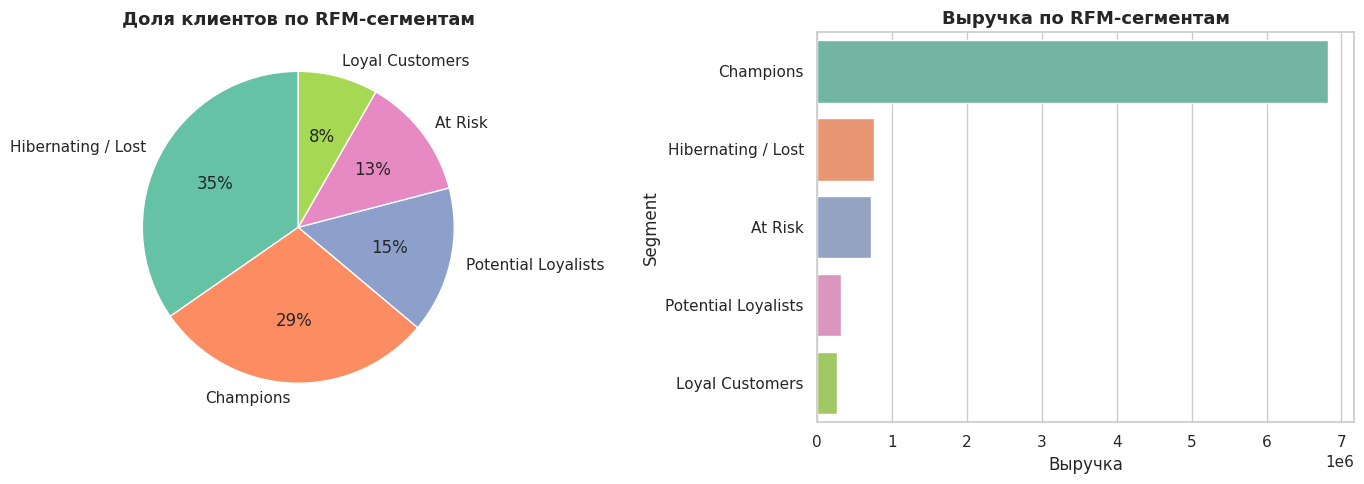

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_counts = rfm["Segment"].value_counts()
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct="%1.0f%%",
            startangle=90, colors=sns.color_palette("Set2"))
axes[0].set_title("Доля клиентов по RFM-сегментам")

segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
sns.barplot(x=segment_revenue.values, y=segment_revenue.index, ax=axes[1], palette="Set2")
axes[1].set_title("Выручка по RFM-сегментам")
axes[1].set_xlabel("Выручка")

plt.tight_layout()
plt.show()


## 7. Анализ товарного ассортимента: принцип Парето (80/20)

Проверяем гипотезу «20% товаров дают 80% выручки» — это напрямую влияет на приоритеты
закупок, продвижения и управления ассортиментом.


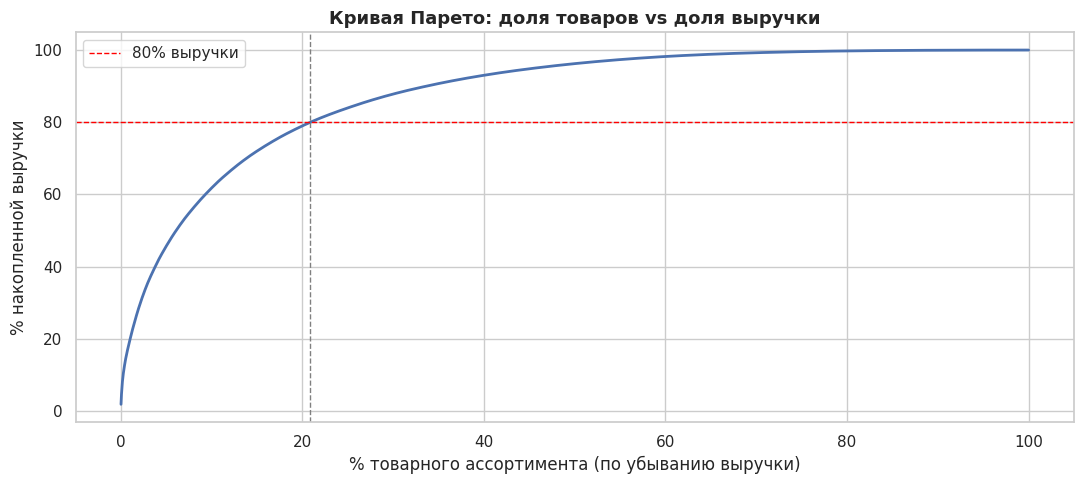

~21% товарного ассортимента формируют 80% выручки.


In [ ]:
product_revenue = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
product_revenue["CumulativeShare"] = (
    product_revenue["TotalPrice"].cumsum() / product_revenue["TotalPrice"].sum()
)
product_revenue["ProductShare"] = (product_revenue.index + 1) / len(product_revenue)

pct_products_for_80 = product_revenue[product_revenue["CumulativeShare"] <= 0.8]["ProductShare"].max()

fig, ax = plt.subplots()
ax.plot(product_revenue["ProductShare"] * 100, product_revenue["CumulativeShare"] * 100, linewidth=2)
ax.axhline(80, color="red", linestyle="--", linewidth=1, label="80% выручки")
if pd.notna(pct_products_for_80):
    ax.axvline(pct_products_for_80 * 100, color="grey", linestyle="--", linewidth=1)
ax.set_title("Кривая Парето: доля товаров vs доля выручки")
ax.set_xlabel("% товарного ассортимента (по убыванию выручки)")
ax.set_ylabel("% накопленной выручки")
ax.legend()
plt.tight_layout()
plt.show()

if pd.notna(pct_products_for_80):
    print(f"~{pct_products_for_80:.0%} товарного ассортимента формируют 80% выручки.")


In [ ]:
from IPython.display import Markdown, display

top_segment = segment_revenue.index[0]
top_segment_share = segment_counts[top_segment] / segment_counts.sum() * 100
top_country = top_countries.index[0]
top_country_share = top_countries.iloc[0] / total_revenue * 100

summary = f"""
### Ключевые цифры проекта

- Общая выручка: **£{total_revenue:,.0f}**, заказов: **{total_orders:,}**,
  клиентов: **{active_customers:,}**, средний чек (AOV): **£{aov:,.2f}**
- Повторные покупки совершают **{repeat_purchase_rate:.0%}** клиентов
- Сегмент **{top_segment}** — {top_segment_share:.0f}% клиентов,
  но формирует наибольшую долю выручки среди RFM-сегментов
- **{top_country}** обеспечивает **{top_country_share:.0f}%** всей выручки
- **{pct_products_for_80:.0%}** товарного ассортимента формирует 80% выручки (Парето)
"""
display(Markdown(summary))


### Ключевые цифры проекта

- Общая выручка: **£8,887,209**, заказов: **18,532**,
  клиентов: **4,338**, средний чек (AOV): **£479.56**
- Повторные покупки совершают **66%** клиентов
- Сегмент **Champions** — 29% клиентов,
  но формирует наибольшую долю выручки среди RFM-сегментов
- **United Kingdom** обеспечивает **82%** всей выручки
- **21%** товарного ассортимента формирует 80% выручки (Парето)


## 8. Выводы и бизнес-рекомендации

### Ключевые находки

1. **Выручка сезонна** — выражены пики в Q4 (ноябрь), что требует заблаговременного
   пополнения складских остатков и раннего старта праздничных кампаний.
2. **Географическая концентрация** — основную выручку формирует небольшое число стран
   (в первую очередь UK), остальные рынки дают заметно меньший вклад. Это одновременно
   риск (зависимость от одного рынка) и точка роста (международная экспансия).
3. **Retention падает уже к 2–3 месяцу когорты** — доля клиентов, возвращающихся за
   повторной покупкой, снижается быстрее всего в первые месяцы жизни клиента. Это
   критическое окно для реактивации.
4. **RFM-сегментация**: небольшая доля клиентов (Champions + Loyal Customers) формирует
   непропорционально большую долю выручки — приоритетная аудитория для удержания.
5. **Принцип Парето подтверждается**: относительно небольшая доля SKU обеспечивает
   основную часть выручки — есть смысл сузить фокус ассортиментной и маркетинговой политики.

### Рекомендации бизнесу

- **Retention/CRM**: запустить триггерные email-кампании реактивации для сегмента
  `At Risk`, пока клиенты не перешли в `Lost`; выстроить onboarding-цепочку для новых
  клиентов в первые 60 дней — именно там теряется больше всего аудитории.
- **VIP-программа**: разработать программу лояльности / персональные предложения для
  `Champions` и `Loyal Customers` — это самый дешёвый способ нарастить выручку.
- **Ассортимент**: пересмотреть закупки и остатки в пользу топ-товаров по Парето-анализу,
  сократить долю низкооборачиваемых позиций.
- **Сезонность**: учитывать пиковые месяцы при планировании запасов, логистики и
  маркетингового бюджета (заранее, за 1–2 месяца до пика).
- **География**: оценить экономику выхода на топ-3 страны вне домашнего рынка как источник
  роста, чтобы снизить зависимость от одного региона.
- **Мониторинг**: внедрить регулярный дашборд (Revenue, AOV, Repeat Purchase Rate,
  RFM-сегменты, Retention по когортам) для отслеживания здоровья продукта в динамике.